In [1]:
import sys
sys.path.insert(0, '../../')

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.base import clone
from tqdm import tqdm
from pickle import load
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

# load local variables
from src.config import *
from src.load_models import select_model
from src.utils import calculate_r2_score, calculate_per_diff
from src.utils import calculate_y_LOD, find_score
from src.feature_selection import ModelSelection
from src.graph_visualization import feature_selection_tabularize, plot_model_vs_score, visualization_class_stratified
from src.outlier_detection import find_outliers_remove
from src.utils import evaluate_score_class_stratified

from sklearn.ensemble  import RandomForestClassifier

from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process.kernels import Matern, RBF

from scipy.stats import ks_2samp
from scipy.stats import ttest_ind, levene

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

In [3]:
y_LOD = 1.0163597575709407

dataset_name = 'ML6'
remove_zero  = True
dataset_root = '../../dataset'

# Load Extracted features dataset
ML6_1 = pd.read_excel(f'{dataset_root}/ML6/Day 1 Data/feature_extraction_noise_None.xlsx')
ML6_2 = pd.read_excel(f'{dataset_root}/ML6/Day 2 Data/feature_extraction_noise_None.xlsx')

ML6_1['dataset_name'] = '1'
ML6_2['dataset_name'] = '2'
final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
final_dataset['label'] = final_dataset['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))

final_dataset.rename(columns={"PH": 'max(S)', 'signal_std':'std(S)', 'signal_mean':'mean(S)', 'peak area':'area(S)', \
                        'dS_dV_area':'area(dS/dV)', 'dS_dV_max_peak':'max(dS/dV)', 'dS_dV_min_peak':'min(dS/dV)',\
                    'dS_dV_peak_diff':'max(dS/dV) - min(dS/dV)', \
                    'peak V':'V_max(S)', 'dS_dV_max_V':'V_max(dS/dV)', 'dS_dV_min_V':'V_min(dS/dV)',\
        }, inplace = True)

final_dataset = final_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2', 'file', 'label']]

X = final_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2']]
Y = final_dataset['label']

In [ ]:
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

In [ ]:


# For each concentration
for label in sorted(Y.unique()):
    X_data_label = X[Y==label]
   
    # Divide the dataset into 2 subsets
    random_shuffle = np.random.choice(len(X_data_label), size=len(X_data_label))
    X_data_label   = X_data_label.iloc[random_shuffle]

    
    X1 = X_data_label[0: len(X_data_label) // 3]
    X2 = X_data_label[len(X_data_label) // 3: 2 * len(X_data_label) // 3]
    X3 = X_data_label[2*len(X_data_label) // 3 :]

    for feature in X_data_label.columns:    
        # Perform one-way ANOVA
        f_stat, p_value = f_oneway(X1[feature].to_list(), X2[feature].to_list(), X3[feature].to_list())
        
        print(f"Label: {label} | Features: {feature} | p-value: {p_value:.4f}")
    print("**********************************")

In [ ]:
print(X1.shape, X2.shape, X3.shape)

In [8]:
def coefficient_of_variation(data):
    mean = np.mean(data)
    std = np.std(data, ddof=1)  # sample standard deviation
    return (std / abs(mean)) * 100

In [ ]:


columns = ['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2']

# For each concentration
all_test_mean = pd.DataFrame(columns=columns)
for random_state in range(100):
    # Remove outliers from training dataset
    train, test           = train_test_split(final_dataset, test_size=0.4, shuffle=True, random_state=random_state, stratify=final_dataset['label'])
    temp = pd.DataFrame([test[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2']].mean()])
    all_test_mean = pd.concat([all_test_mean, temp], ignore_index=False)

cv_df   = pd.DataFrame(columns=columns)

cv_dict = {'Features':[], "CV":[]}
for feature in columns:
    cv = coefficient_of_variation(all_test_mean[feature])
    cv_dict['Features'].append(feature)
    cv_dict['CV'].append(cv)
    
cv_df = pd.DataFrame(cv_dict)
cv_df

In [ ]:
cv_df.plot(x='Features', y='CV', kind='bar')

In [29]:
final_dataset

,area(S),max(S),max(dS/dV),min(dS/dV),V_max(S),vcenter,V_max(dS/dV),V_min(dS/dV),f1,f2,file,label
0,1.1035,0.017510,0.3809,-0.5244,1.0509,1.0463,1.032,1.080,0.7072,-16.8102,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,4
1,2.2940,0.033824,0.6989,-0.8795,1.0582,1.0480,1.036,1.092,1.3894,34.8073,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,4
2,3.1824,0.051996,1.2167,-1.4382,1.0461,1.0538,1.016,1.072,1.5455,34.8061,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,8
3,3.1574,0.054249,1.2173,-1.6441,1.0484,1.0491,1.020,1.076,1.0457,-4.3396,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,8
4,5.5264,0.090447,2.1041,-2.5004,1.0657,1.0712,1.036,1.092,1.2007,25.1452,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,16
...,...,...,...,...,...,...,...,...,...,...,...,...
220,8.8870,0.136665,2.9070,-3.4862,1.0594,1.0619,1.028,1.088,1.4306,44.7135,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,16
221,2.0187,0.031516,0.6744,-0.8230,1.0517,1.0510,1.020,1.076,1.1217,14.4177,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,8
222,4.3946,0.065702,1.3993,-1.5154,1.0545,1.0570,1.016,1.084,0.9395,35.8728,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,12
223,1.8908,0.024186,0.5026,-0.6235,1.0352,1.0270,1.016,1.076,0.7506,-3.4662,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,4


# CV label stratified

In [28]:
all_stratified = {}
feature_list   = ['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2']

labels         = sorted(final_dataset['label'].unique())
cv_dict        = {'Features':feature_list, "0":[], "4":[], "8":[], "12":[], "16":[]}

all_test_mean  = {str(label): pd.DataFrame(columns=feature_list) for label in labels}

for random_state in range(100):
    _, test           = train_test_split(final_dataset, test_size=0.4, shuffle=True, random_state=random_state, stratify=final_dataset['label'])

    for label in labels:
        # Select only the dataset with specific label
        label_wise_dataset = test[test['label']==label]
        temp = pd.DataFrame([label_wise_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2']].mean()])
        all_test_mean[str(label)] = pd.concat([all_test_mean[str(label)], temp], ignore_index=False)
        

# Perform random splitting of dataset


for feature in feature_list:
    cv['Features'].append(feature)
    for label in labels:
        cv = coefficient_of_variation(all_test_mean[feature])
        cv_dict[str(label)].append(cv)

cv_df = pd.DataFrame(cv_dict) 
cv_df

KeyError: 'label'

<Axes: xlabel='Features'>

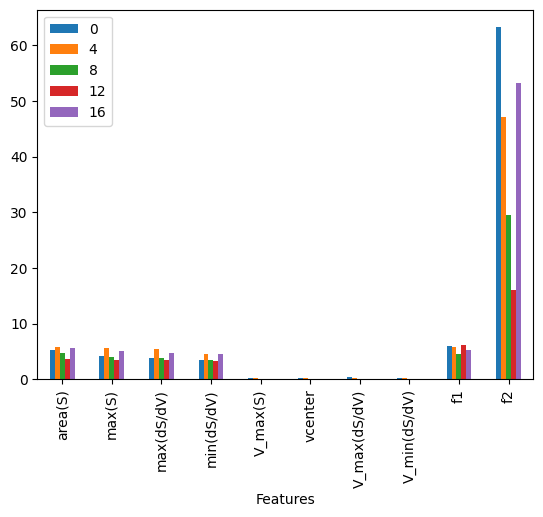

In [23]:
cv_df.plot(x="Features", y=[str(i) for i in labels], kind='bar')

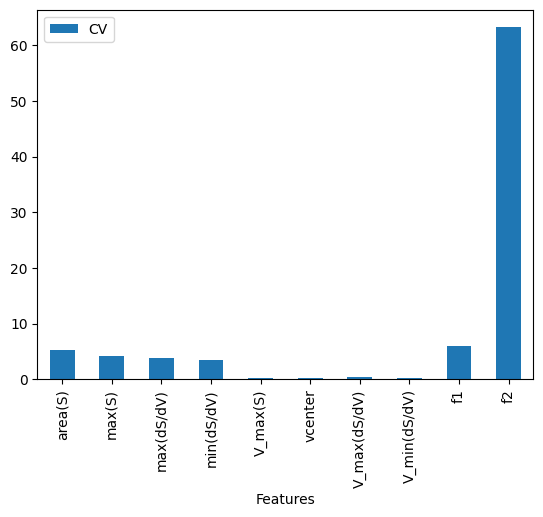

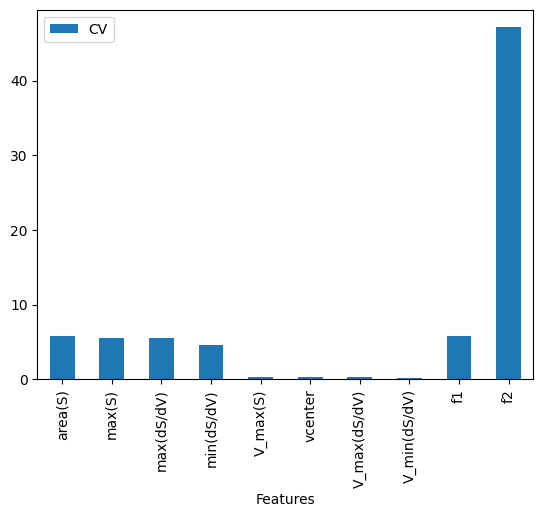

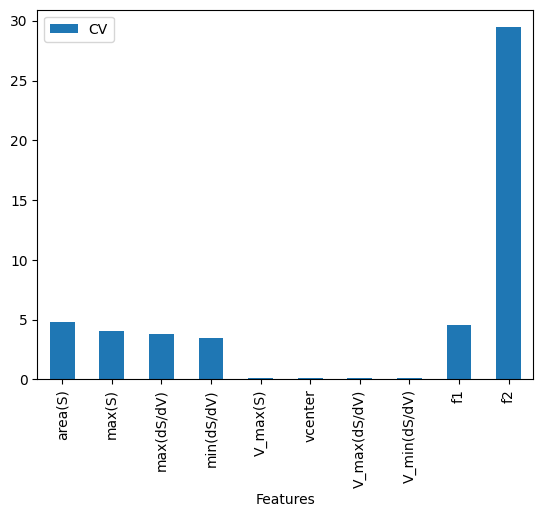

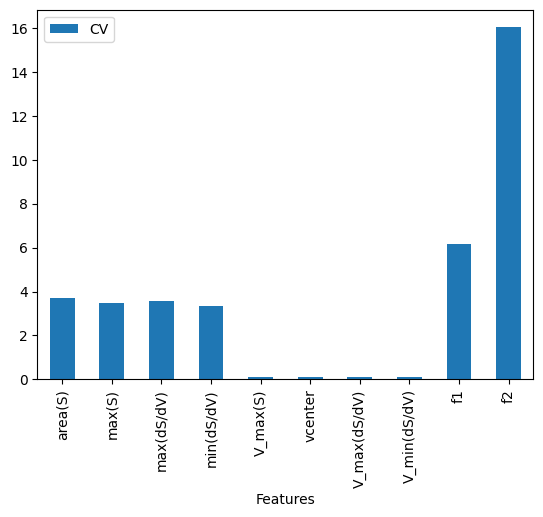

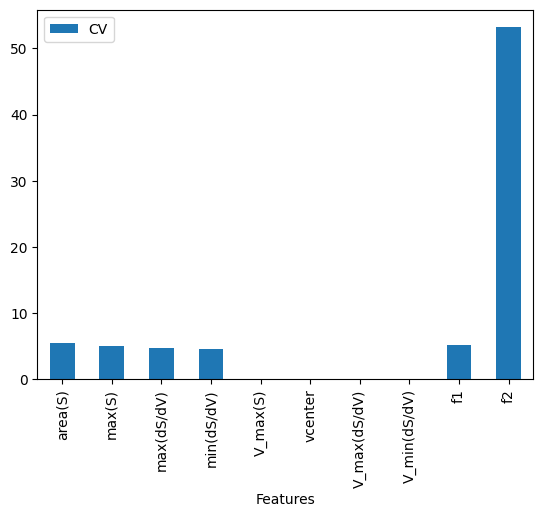

In [15]:
for label in sorted(final_dataset['label'].unique()):
    df = cv_df[cv_df['label']==label]
    df.plot(x='Features', y='CV', kind='bar')